# ЛР № 1. Признаковые описания и метрики

Вариант 4: `p = 4` (метрика Минковского в шаге 4), `lambda = -2` (K-расстояние по Колмогорову).
Дополнительное задание — расстояние Канберры между классами Iris и его отличие от d2.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance as scipy_dist
from sklearn.datasets import load_iris, load_wine, load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

RANDOM_STATE = 42
VARIANT = 4
MINKOWSKI_P = 4
KOLMOGOROV_LAMBDA = -2

np.set_printoptions(precision=4, suppress=True)

## Шаг 1. Загрузка данных

Для каждого набора: `X.shape`, `y.shape`, число классов, размерность, объём выборки, имена признаков, доли классов.

In [2]:
def describe_dataset(name, data):
    """Вывести сводку по датасету sklearn.

    Вход: имя набора, объект Bunch из sklearn.datasets.
    Выход: None (печатает X.shape, y.shape, m, n, N, имена признаков, доли классов).
    """
    X, y = data.data, data.target
    classes, counts = np.unique(y, return_counts=True)
    print(f"--- {name} ---")
    print("X.shape:", X.shape, "y.shape:", y.shape)
    print("Число классов m:", len(classes), "размерность n:", X.shape[1], "объём N:", X.shape[0])
    print("Признаки:", list(data.feature_names))
    print("Доли классов:", dict(zip(classes, np.round(counts / counts.sum(), 3))))
    print()

iris = load_iris()
wine = load_wine()
digits = load_digits()

for name, ds in (("Iris", iris), ("Wine", wine), ("Digits", digits)):
    describe_dataset(name, ds)

--- Iris ---
X.shape: (150, 4) y.shape: (150,)
Число классов m: 3 размерность n: 4 объём N: 150
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Доли классов: {np.int64(0): np.float64(0.333), np.int64(1): np.float64(0.333), np.int64(2): np.float64(0.333)}

--- Wine ---
X.shape: (178, 13) y.shape: (178,)
Число классов m: 3 размерность n: 13 объём N: 178
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Доли классов: {np.int64(0): np.float64(0.331), np.int64(1): np.float64(0.399), np.int64(2): np.float64(0.27)}

--- Digits ---
X.shape: (1797, 64) y.shape: (1797,)
Число классов m: 10 размерность n: 64 объём N: 1797
Признаки: ['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4', 'pixel_0_5', 'pixel_0_6', 'pixel_0_7', 'pixel_1_0', 'pixel_1_1', 'pixel_1_2', 'pixel_1_3',

## Шаг 2. Метрики пространства признаков

In [3]:
def d_euclid(x, y):
    """Евклидова метрика d2(x, y) = sqrt(sum((x_i - y_i)^2))."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return np.sqrt(np.sum((x - y) ** 2, axis=-1))


def d_minkowski(x, y, p=2.0):
    """Метрика Минковского d_p.

    При p=2 - Евклид; p=1 - Манхэттен; p -> inf - доминирование.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return np.power(np.sum(np.abs(x - y) ** p, axis=-1), 1.0 / p)


def d_chebyshev(x, y):
    """Метрика доминирования d_inf(x, y) = max_i |x_i - y_i|."""
    return np.max(np.abs(np.asarray(x) - np.asarray(y)), axis=-1)


def d_canberra(x, y):
    """Метрика Канберра d_k(x, y) = sum |x_i - y_i| / (|x_i| + |y_i|)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    num = np.abs(x - y)
    den = np.abs(x) + np.abs(y)
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(den > 0, num / den, 0.0)
    return np.sum(ratio, axis=-1)


def cosine_dist(x, y):
    """Косинусное расстояние alpha(x, y) = arccos(x^T y / (|x| |y|))."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    num = np.sum(x * y, axis=-1)
    den = np.sqrt(np.sum(x * x, axis=-1)) * np.sqrt(np.sum(y * y, axis=-1))
    cos = np.clip(num / den, -1.0, 1.0)
    return np.arccos(cos)


def d_mahalanobis(x, y, S_inv):
    """Метрика Махаланобиса d_S^-1(x, y) = (x - y)^T S^-1 (x - y)."""
    v = np.asarray(x, dtype=float) - np.asarray(y, dtype=float)
    return v @ S_inv @ v

In [4]:
# Unit-тесты: сравнение с эталонными реализациями scipy.spatial.distance
rng = np.random.default_rng(RANDOM_STATE)
x_test, y_test = rng.normal(size=5), rng.normal(size=5)
cov = np.cov(rng.normal(size=(5, 20)))
cov_inv = np.linalg.inv(cov)

checks = [
    ("d_euclid", d_euclid(x_test, y_test), scipy_dist.euclidean(x_test, y_test)),
    ("d_minkowski(p=3)", d_minkowski(x_test, y_test, 3), scipy_dist.minkowski(x_test, y_test, 3)),
    ("d_chebyshev", d_chebyshev(x_test, y_test), scipy_dist.chebyshev(x_test, y_test)),
    ("d_canberra", d_canberra(x_test, y_test), scipy_dist.canberra(x_test, y_test)),
    ("cosine_dist", cosine_dist(x_test, y_test), np.arccos(1 - scipy_dist.cosine(x_test, y_test))),
    ("d_mahalanobis", d_mahalanobis(x_test, y_test, cov_inv), scipy_dist.mahalanobis(x_test, y_test, cov_inv) ** 2),
]
for name, mine, ref in checks:
    print(f"{name}: mine={mine:.6f} scipy={ref:.6f} ok={np.isclose(mine, ref)}")

d_euclid: mine=2.684381 scipy=2.684381 ok=True
d_minkowski(p=3): mine=2.092095 scipy=2.092095 ok=True
d_chebyshev: mine=1.606897 scipy=1.606897 ok=True
d_canberra: mine=4.391569 scipy=4.391569 ok=True
cosine_dist: mine=1.350899 scipy=1.350899 ok=True
d_mahalanobis: mine=16.131324 scipy=16.131324 ok=True


## Шаг 3. Статистики класса и расстояние точка–класс

In [5]:
def class_stats(X_class):
    """Вычислить m и S класса по формулам (8), (9).

    Вход: X_class (m, n) - строки суть образы класса.
    Выход: (m вектор среднего (n,), S ковариационная матрица (n, n)).
    """
    X_class = np.asarray(X_class, dtype=float)
    m = X_class.mean(axis=0)
    Xc = X_class - m
    S = Xc.T @ Xc / X_class.shape[0]
    return m, S


def dist_point_class(x, X_class, mode="euclid_mean"):
    """Расстояние точка-класс.

    mode: 'euclid_mean' (d2 до m), 'diag' (формула (10), евклид с учётом дисперсий),
    'mahalanobis' (формула (11)), 'nearest' (до ближайшего представителя класса).
    """
    x = np.asarray(x, dtype=float)
    X_class = np.asarray(X_class, dtype=float)
    m, S = class_stats(X_class)

    if mode == "euclid_mean":
        return d_euclid(x, m)
    if mode == "diag":
        D = np.diag(S)
        v = x - m
        return v @ np.diag(1.0 / D) @ v
    if mode == "mahalanobis":
        S_inv = np.linalg.inv(S)
        return d_mahalanobis(x, m, S_inv)
    if mode == "nearest":
        return np.min(d_euclid(x, X_class))
    raise ValueError(f"unknown mode: {mode}")

In [6]:
# Проверка на классах Iris для точки (6.0, 3.0, 4.5, 1.5)
probe_point = np.array([6.0, 3.0, 4.5, 1.5])
modes = ("euclid_mean", "diag", "mahalanobis", "nearest")

print("Расстояния точки до классов Iris:")
for c in np.unique(iris.target):
    X_c = iris.data[iris.target == c]
    row = {mode: round(float(dist_point_class(probe_point, X_c, mode)), 3) for mode in modes}
    print(iris.target_names[c], row)

Расстояния точки до классов Iris:
setosa {'euclid_mean': 3.46, 'diag': 466.165, 'mahalanobis': 388.16, 'nearest': 3.069}
versicolor {'euclid_mean': 0.381, 'diag': 1.62, 'mahalanobis': 1.08, 'nearest': 0.1}
virginica {'euclid_mean': 1.315, 'diag': 8.329, 'mahalanobis': 9.893, 'nearest': 0.424}


## Шаг 4. Расстояния между классами и визуализация

In [7]:
def dist_class_class_min(X1, X2):
    """Расстояние ближнего соседа между классами (формула (12))."""
    X1, X2 = np.asarray(X1, dtype=float), np.asarray(X2, dtype=float)
    D = np.linalg.norm(X1[:, None, :] - X2[None, :, :], axis=-1)
    return D.min()


def dist_class_class_max(X1, X2):
    """Расстояние дальнего соседа между классами (формула (13))."""
    X1, X2 = np.asarray(X1, dtype=float), np.asarray(X2, dtype=float)
    D = np.linalg.norm(X1[:, None, :] - X2[None, :, :], axis=-1)
    return D.max()


def dist_class_class_kolmogorov(X1, X2, lam):
    """K-расстояние по Колмогорову между классами (формула (14)).

    lam -> +inf даёт расстояние дальнего соседа, lam -> -inf - ближнего.
    """
    X1, X2 = np.asarray(X1, dtype=float), np.asarray(X2, dtype=float)
    D = np.linalg.norm(X1[:, None, :] - X2[None, :, :], axis=-1)
    return np.power(np.mean(D ** lam), 1.0 / lam)

In [8]:
iris_classes = [iris.data[iris.target == c] for c in np.unique(iris.target)]
n_classes = len(iris_classes)


def pairwise_matrix(func):
    M = np.zeros((n_classes, n_classes))
    for i in range(n_classes):
        for j in range(n_classes):
            if i != j:
                M[i, j] = func(iris_classes[i], iris_classes[j])
    return M


print("Матрица ближнего соседа:\n", np.round(pairwise_matrix(dist_class_class_min), 3))
print("Матрица дальнего соседа:\n", np.round(pairwise_matrix(dist_class_class_max), 3))
print(f"Матрица Колмогорова (lambda={KOLMOGOROV_LAMBDA}):\n",
      np.round(pairwise_matrix(lambda a, b: dist_class_class_kolmogorov(a, b, KOLMOGOROV_LAMBDA)), 3))

Матрица ближнего соседа:
 [[0.    1.64  3.135]
 [1.64  0.    0.224]
 [3.135 0.224 0.   ]]
Матрица дальнего соседа:
 [[0.    4.851 7.085]
 [4.851 0.    4.839]
 [7.085 4.839 0.   ]]
Матрица Колмогорова (lambda=-2):
 [[0.    3.144 4.676]
 [3.144 0.    1.283]
 [4.676 1.283 0.   ]]


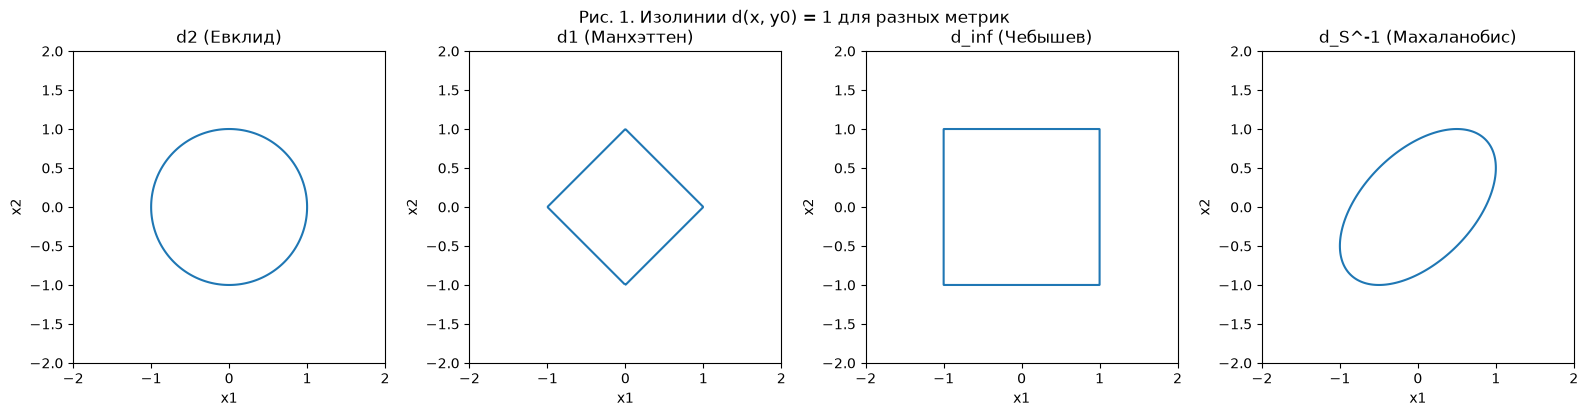

In [9]:
# Изолинии метрик d2, d1, d_inf, d_S^-1 вокруг y0 = (0, 0), уровень r = 1
y0 = np.array([0.0, 0.0])
grid = np.linspace(-2, 2, 400)
gx, gy = np.meshgrid(grid, grid)
pts = np.stack([gx, gy], axis=-1)

S_demo = np.array([[1.0, 0.5], [0.5, 1.0]])
S_demo_inv = np.linalg.inv(S_demo)

fields = {
    "d2 (Евклид)": np.linalg.norm(pts - y0, axis=-1),
    "d1 (Манхэттен)": np.sum(np.abs(pts - y0), axis=-1),
    "d_inf (Чебышев)": np.max(np.abs(pts - y0), axis=-1),
    "d_S^-1 (Махаланобис)": np.einsum("...i,ij,...j->...", pts - y0, S_demo_inv, pts - y0),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, field) in zip(axes, fields.items()):
    level = 1.0 if "Махаланобис" not in title else 1.0
    ax.contour(gx, gy, field, levels=[level], colors="tab:blue")
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.set_aspect("equal")
fig.suptitle("Рис. 1. Изолинии d(x, y0) = 1 для разных метрик")
fig.tight_layout()
plt.show()

## Шаг 5. Классификатор «ближайший центр» на Wine

In [10]:
def nearest_mean_classify(X_train, y_train, X_test, metric="euclid"):
    """Классификатор ближайшего центра. Возвращает предсказанные метки."""
    classes = np.unique(y_train)
    means = np.stack([X_train[y_train == c].mean(axis=0) for c in classes])
    if metric == "mahalanobis":
        Ss = [class_stats(X_train[y_train == c])[1] for c in classes]
        S_bar = np.mean(Ss, axis=0)
        S_inv = np.linalg.pinv(S_bar)
        dists = np.stack([[d_mahalanobis(x, mu, S_inv) for mu in means] for x in X_test])
    else:
        dists = np.linalg.norm(X_test[:, None, :] - means[None, :, :], axis=2)
    return classes[np.argmin(dists, axis=1)]


X_tr, X_te, y_tr, y_te = train_test_split(
    wine.data, wine.target, test_size=0.25, stratify=wine.target,
    random_state=RANDOM_STATE,
)
for metric in ("euclid", "mahalanobis"):
    y_hat = nearest_mean_classify(X_tr, y_tr, X_te, metric=metric)
    print(f"metric={metric}: accuracy={accuracy_score(y_te, y_hat):.3f}")
    print(confusion_matrix(y_te, y_hat))

metric=euclid: accuracy=0.756
[[13  0  2]
 [ 0 13  5]
 [ 0  4  8]]
metric=mahalanobis: accuracy=0.978
[[15  0  0]
 [ 1 17  0]
 [ 0  0 12]]


## Индивидуальное задание (вариант 4): расстояние Канберры между классами Iris vs d2

In [11]:
def dist_class_class_canberra_mean(X1, X2):
    """Расстояние Канберры между центрами классов (для сравнения с d2 между классами)."""
    m1, _ = class_stats(X1)
    m2, _ = class_stats(X2)
    return float(d_canberra(m1, m2))


def dist_class_class_euclid_mean(X1, X2):
    """Евклидово расстояние между центрами классов."""
    m1, _ = class_stats(X1)
    m2, _ = class_stats(X2)
    return float(d_euclid(m1, m2))


print("Канберра между центрами классов Iris:\n", np.round(pairwise_matrix(dist_class_class_canberra_mean), 3))
print("d2 между центрами классов Iris:\n", np.round(pairwise_matrix(dist_class_class_euclid_mean), 3))

Канберра между центрами классов Iris:
 [[0.    1.367 1.574]
 [1.367 0.    0.428]
 [1.574 0.428 0.   ]]
d2 между центрами классов Iris:
 [[0.    3.208 4.755]
 [3.208 0.    1.62 ]
 [4.755 1.62  0.   ]]


## Выводы

TODO: сформулировать не менее 3 предложений о том, чем содержательно различаются метрики, опираясь на числа выше.

## Контрольные вопросы

TODO: ответить полными предложениями на вопросы из п. 1.9 методички.